In [1]:
# Hugging Face Dataset Experiment
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 24.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 28.9 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 16.1.0
    Uninstalling pyarrow-16.1.0:
      Successfully uninstalled pyarrow-16.1.0
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: click
    Found existing installation: click 8.1.7
    Uninstalling click-8.1.7:
      Successfully uninstalled click-8.1.7
  Attempting uninstall: rich
    Found existing installation: rich 13.7.1
    Uninstalling rich-13.7.1:
      Successfully uninstalled rich-13.7.1
  Attempting uninstall: typer
    Found existing installation: typer 0.9.0

In [10]:
import pandas as pd
import numpy as np

from datasets import load_dataset

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
hf_dataset = load_dataset(
    "Fatima0923/Automated-Personality-Prediction"
)

hf_train = pd.DataFrame(hf_dataset["train"])
hf_val = pd.DataFrame(hf_dataset["validation"])
hf_test = pd.DataFrame(hf_dataset["test"])

hf_df = pd.concat(
    [hf_train, hf_val, hf_test],
    ignore_index=True
)

print(hf_df.shape)

hf_df.head()

(20877, 6)


,text,agreeableness,openness,conscientiousness,extraversion,neuroticism
0,his name was kim kimble originally wow thats s...,9.0,61.0,13.0,4.0,72.0
1,theyre better than the normal posts on ryugioh...,50.0,85.0,50.0,85.0,50.0
2,how the fuck does this even happen hi youre cu...,15.0,85.0,15.0,85.0,15.0
3,it probably does ive learned a lot about mysel...,71.0,53.0,17.0,3.0,31.0
4,yea those are the same sound to me still,64.0,44.0,33.0,8.0,88.0


In [12]:
# create ocean df
hf_ocean_cols = [
    "openness",
    "conscientiousness",
    "extraversion",
    "agreeableness",
    "neuroticism"
]

hf_ocean = hf_df[hf_ocean_cols]

hf_ocean.describe()

,openness,conscientiousness,extraversion,agreeableness,neuroticism
count,20877.000000,20877.000000,20877.000000,20877.000000,20877.000000
mean,67.662475,32.063946,34.992144,39.319514,46.519327
std,22.809369,27.568728,30.619385,29.451380,28.056181
min,9.000000,1.000000,0.000000,0.000000,0.000000
25%,50.000000,13.000000,7.000000,10.000000,19.000000
50%,74.000000,25.000000,24.000000,39.000000,50.000000
75%,85.000000,49.000000,60.000000,57.000000,72.000000
max,98.000000,98.000000,99.000000,99.000000,99.000000


In [13]:
# standardize
scaler = StandardScaler()

hf_scaled = scaler.fit_transform(
    hf_ocean
)

In [14]:
K = 6

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

hf_labels = kmeans.fit_predict(
    hf_scaled
)

hf_centroids = kmeans.cluster_centers_

hf_inertia = kmeans.inertia_

hf_silhouette = silhouette_score(
    hf_scaled,
    hf_labels
)

print("HF Silhouette:",
      round(hf_silhouette,4))

print("HF Inertia:",
      round(hf_inertia,2))

HF Silhouette: 0.3426
HF Inertia: 40546.41


In [16]:
hf_centroids_original = scaler.inverse_transform(
    hf_centroids
)

hf_profiles = pd.DataFrame(
    hf_centroids_original,
    columns=hf_ocean_cols
)

hf_profiles.index = [
    f"Cluster {i}"
    for i in range(K)
]

hf_profiles.round(2)

,openness,conscientiousness,extraversion,agreeableness,neuroticism
Cluster 0,36.19,31.05,12.96,68.77,71.95
Cluster 1,77.87,17.88,73.75,11.67,29.04
Cluster 2,71.83,11.87,19.54,20.44,75.52
Cluster 3,76.36,86.77,14.67,34.21,16.57
Cluster 4,75.09,23.12,25.14,52.72,25.39
Cluster 5,76.36,63.41,78.08,45.62,42.83


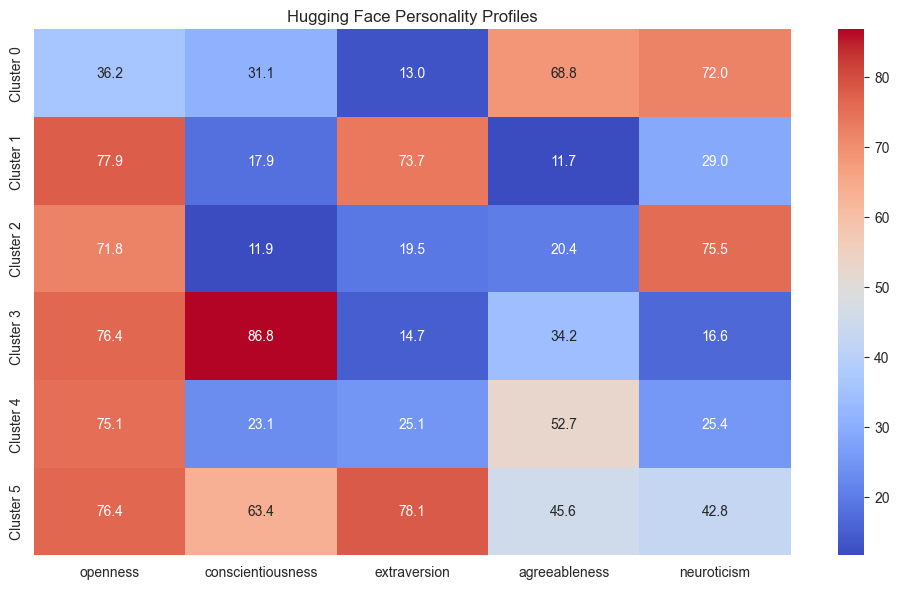

In [17]:
plt.figure(figsize=(10,6))

sns.heatmap(
    hf_profiles,
    annot=True,
    cmap="coolwarm",
    fmt=".1f"
)

plt.title(
    "Hugging Face Personality Profiles"
)

plt.tight_layout()

plt.show()